In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import pandas as pd

# Load datasets
customers = pd.read_csv("data/olist_customers_dataset.csv")
orders = pd.read_csv("data/olist_orders_dataset.csv")
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
payments = pd.read_csv("data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
products = pd.read_csv("data/olist_products_dataset.csv")
sellers = pd.read_csv("data/olist_sellers_dataset.csv")
geo = pd.read_csv("data/olist_geolocation_dataset.csv")
category = pd.read_csv("data/product_category_name_translation.csv")

In [2]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
orders.shape

(99441, 8)

In [4]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [5]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [6]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [10]:
delivered_orders = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].notnull())
].copy()

In [11]:
delivered_orders.shape

(96470, 8)

In [12]:
delivered_orders['order_purchase_timestamp'] = pd.to_datetime(
    delivered_orders['order_purchase_timestamp']
)

delivered_orders['order_delivered_customer_date'] = pd.to_datetime(
    delivered_orders['order_delivered_customer_date']
)

delivered_orders['order_estimated_delivery_date'] = pd.to_datetime(
    delivered_orders['order_estimated_delivery_date']
)

In [13]:
delivered_orders['month'] = delivered_orders['order_purchase_timestamp'].dt.month
delivered_orders['year'] = delivered_orders['order_purchase_timestamp'].dt.year

In [14]:
delivered_orders['delivery_time'] = (
    delivered_orders['order_delivered_customer_date'] -
    delivered_orders['order_purchase_timestamp']
).dt.days

In [15]:
delivered_orders[['order_purchase_timestamp','month','year','delivery_time']].head()

,order_purchase_timestamp,month,year,delivery_time
0,2017-10-02 10:56:33,10,2017,8
1,2018-07-24 20:41:37,7,2018,13
2,2018-08-08 08:38:49,8,2018,9
3,2017-11-18 19:28:06,11,2017,13
4,2018-02-13 21:18:39,2,2018,2


In [16]:
delivered_orders['delivery_time'].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time, dtype: float64

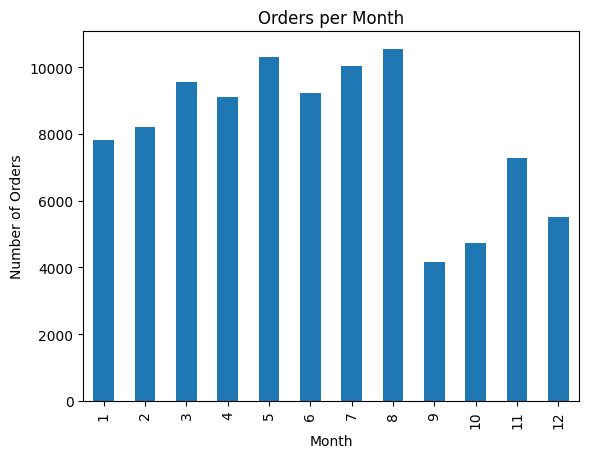

In [19]:
delivered_orders.groupby('month').size().plot(kind='bar')
plt.title("Orders per Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

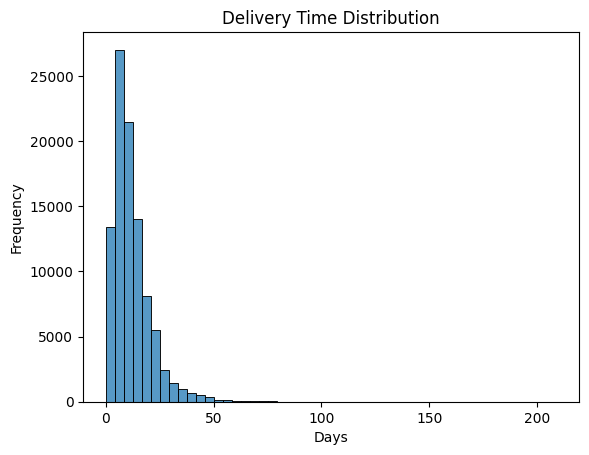

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(delivered_orders['delivery_time'], bins=50)
plt.title("Delivery Time Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

### Delivery Time Analysis

- The average delivery time is approximately 12 days, with a median of 10 days.
- Most orders are delivered within 6 to 15 days.
- The distribution is right-skewed, indicating the presence of delayed deliveries.
- Some extreme outliers exist, with delivery times exceeding 200 days.
- These outliers may indicate logistical inefficiencies or data quality issues.

In [21]:
#Calculate Delivery Delay
delivered_orders['delivery_delay'] = (
    delivered_orders['order_delivered_customer_date'] -
    delivered_orders['order_estimated_delivery_date']
).dt.days

In [22]:
delivered_orders['delivery_delay'].describe()

count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay, dtype: float64

In [23]:
#Check On-Time vs Late
delivered_orders['delivery_status'] = delivered_orders['delivery_delay'].apply(
    lambda x: 'On Time' if x <= 0 else 'Late'
)

delivered_orders['delivery_status'].value_counts()

delivery_status
On Time    89936
Late        6534
Name: count, dtype: int64

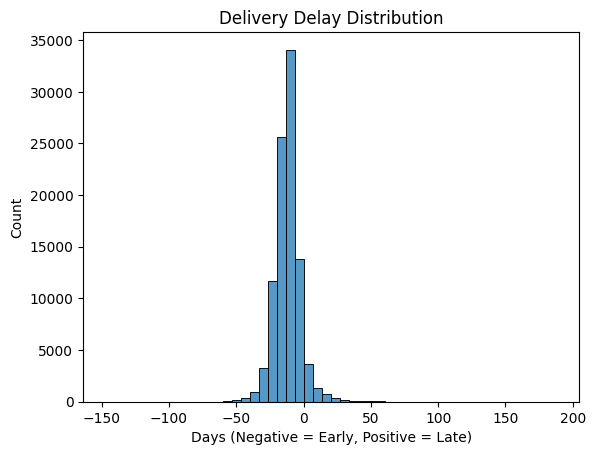

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(delivered_orders['delivery_delay'], bins=50)
plt.title("Delivery Delay Distribution")
plt.xlabel("Days (Negative = Early, Positive = Late)")
plt.show()

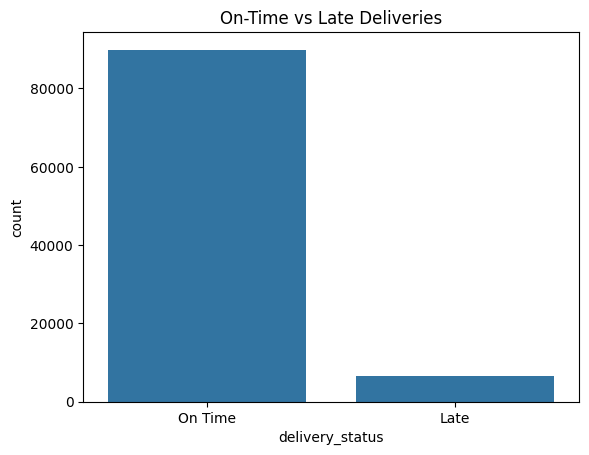

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=delivered_orders, x='delivery_status')
plt.title("On-Time vs Late Deliveries")
plt.show()

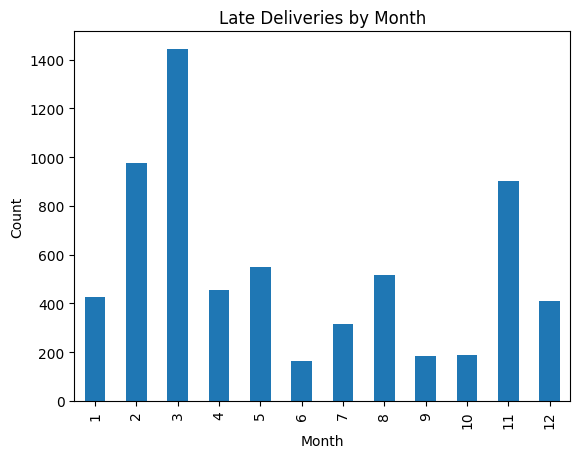

In [25]:
late_orders = delivered_orders[delivered_orders['delivery_status'] == 'Late']

late_orders.groupby('month').size().plot(kind='bar')
plt.title("Late Deliveries by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

In [ ]:
#Merge Orders + Payments
# Merge datasets
revenue_df = delivered_orders.merge(payments, on='order_id')

In [ ]:
#Total Revenue
revenue_df['payment_value'].sum()

np.float64(15421082.85)

In [ ]:
#Revenue per Order
revenue_df.groupby('order_id')['payment_value'].sum().head()

order_id
00010242fe8c5a6d1ba2dd792cb16214     72.19
00018f77f2f0320c557190d7a144bdd3    259.83
000229ec398224ef6ca0657da4fc703e    216.87
00024acbcdf0a6daa1e931b038114c75     25.78
00042b26cf59d7ce69dfabb4e55b4fd9    218.04
Name: payment_value, dtype: float64

In [30]:
#Monthly Revenue
monthly_revenue = revenue_df.groupby(['year', 'month'])['payment_value'].sum().reset_index()

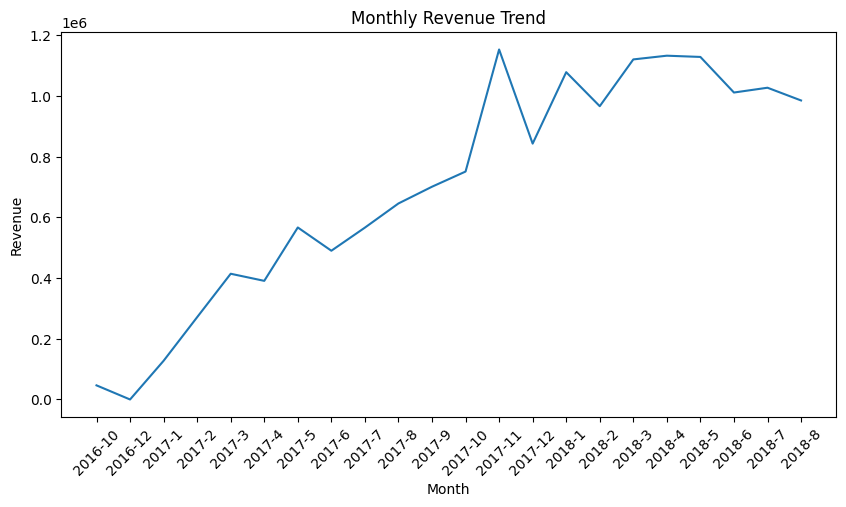

In [31]:
#Plot Monthly Revenue
import matplotlib.pyplot as plt

monthly_revenue['year_month'] = monthly_revenue['year'].astype(str) + '-' + monthly_revenue['month'].astype(str)

plt.figure(figsize=(10,5))
plt.plot(monthly_revenue['year_month'], monthly_revenue['payment_value'])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [32]:
#Top Revenue Months
monthly_revenue.sort_values(by='payment_value', ascending=False).head()

,year,month,payment_value,year_month
12,2017,11,1153393.22,2017-11
17,2018,4,1132933.95,2018-4
18,2018,5,1128836.69,2018-5
16,2018,3,1120678.00,2018-3
14,2018,1,1078606.86,2018-1


In [34]:
#Payment Type Analysis
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [35]:
payments.groupby('payment_type')['payment_value'].sum()

payment_type
boleto          2869361.27
credit_card    12542084.19
debit_card       217989.79
not_defined           0.00
voucher          379436.87
Name: payment_value, dtype: float64

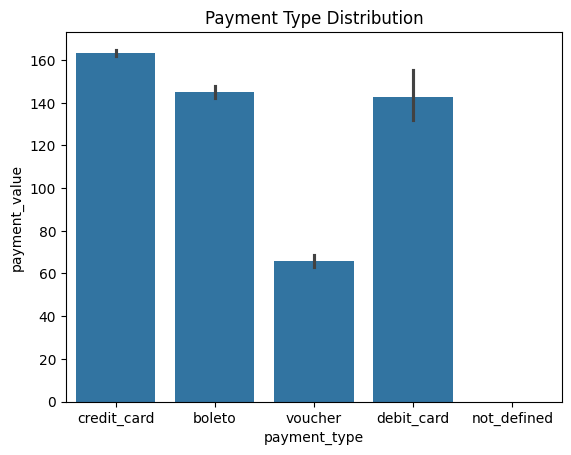

In [36]:
#Visualization
import seaborn as sns

sns.barplot(x=payments['payment_type'], y=payments['payment_value'])
plt.title("Payment Type Distribution")
plt.show()

In [37]:
#STEP 1: Merge Required Datasets
product_df = order_items.merge(products, on='product_id')
product_df = product_df.merge(category, on='product_category_name', how='left')

In [38]:
#STEP 2: Top Selling Products
top_products = product_df['product_id'].value_counts().head(10)
top_products

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
Name: count, dtype: int64

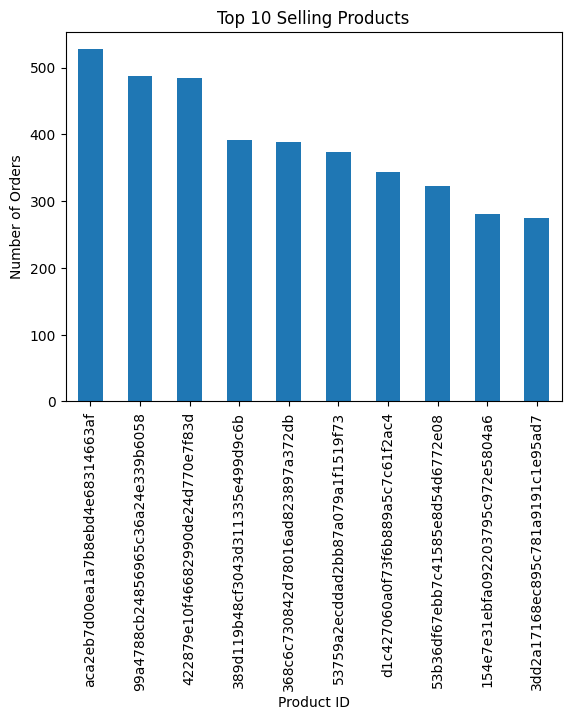

In [39]:
#Visualize Top Products
import matplotlib.pyplot as plt

top_products.plot(kind='bar')
plt.title("Top 10 Selling Products")
plt.xlabel("Product ID")
plt.ylabel("Number of Orders")
plt.show()

In [40]:
#STEP 3: Top Categories
top_categories = product_df['product_category_name_english'].value_counts().head(10)
top_categories

product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64

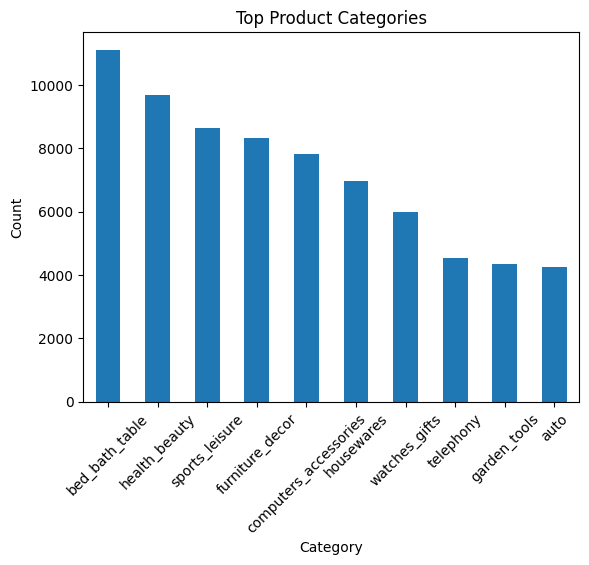

In [41]:
#Visualize Categories
top_categories.plot(kind='bar')
plt.title("Top Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [42]:
#STEP 4: Revenue by Category
category_revenue = product_df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)
category_revenue

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

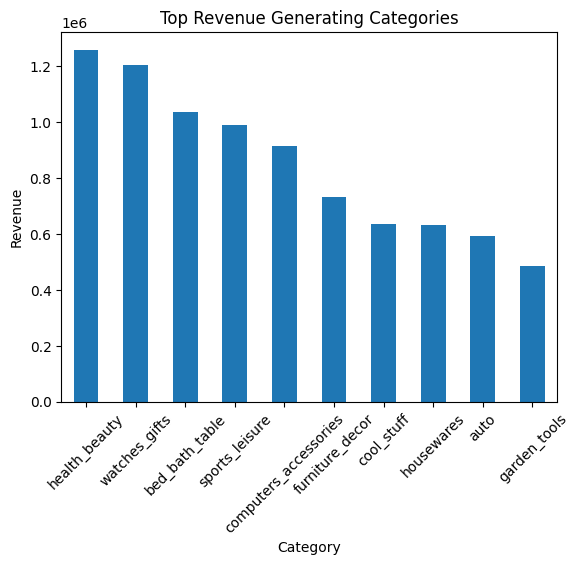

In [43]:
#Visualize Revenue
category_revenue.plot(kind='bar')
plt.title("Top Revenue Generating Categories")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [44]:
#STEP 5: Average Price per Category
avg_price = product_df.groupby('product_category_name_english')['price'].mean().sort_values(ascending=False).head(10)
avg_price

product_category_name_english
computers                                1098.340542
small_appliances_home_oven_and_coffee     624.285658
home_appliances_2                         476.124958
agro_industry_and_commerce                342.124858
musical_instruments                       281.616000
small_appliances                          280.778468
fixed_telephony                           225.693182
construction_tools_safety                 208.992371
watches_gifts                             201.135984
air_conditioning                          185.269226
Name: price, dtype: float64

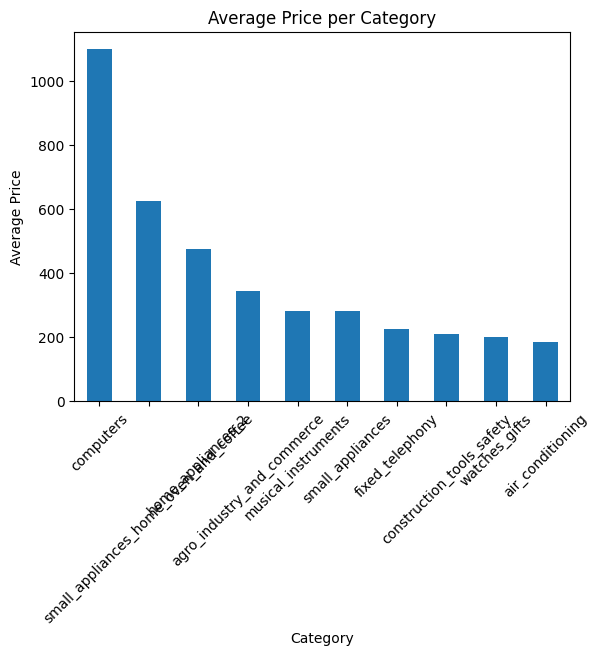

In [45]:
avg_price.plot(kind='bar')
plt.title("Average Price per Category")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()